# Supplementary Figure S3 - Null Validation

Two independent null-model controls for the yeast GI-PCC reference clustering (`linkage_method="ward"`, `linkage_metric="euclidean"`, `linkage_threshold=16`, `min_cluster_size=30`, `min_overlap=2`, global Benjamini-Hochberg FDR, `qval <= 0.05`; 7 clusters, 709 enriched rows, 331 significant cluster-term pairs): an annotation-label permutation null and a same-size cluster-randomization null. Both address whether the observed enrichment could arise from arbitrary labels or arbitrary cluster partitions rather than genuine structure.

In [1]:
# Enable inline plotting for notebooks
%matplotlib inline

In [2]:
# Figure export utilities (PNG, 300 DPI).
from pathlib import Path

import matplotlib.pyplot as plt

PNG_DIR = Path("png") / "supp_fig_3"
PNG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure_png(name, *, fig=None, dpi=300, pad_inches=0.02):
    """Save a Matplotlib figure as a high-quality PNG in the notebook export folder."""
    if fig is None:
        fig = plt.gcf()
    output_path = PNG_DIR / f"{name}.png"
    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=pad_inches,
        facecolor=fig.get_facecolor(),
        edgecolor="none",
    )
    print(f"Saved {output_path}")
    return output_path

## Load Evidence

Load the pre-computed null distributions and observed-vs-null summaries from the validated
revision notebooks (`revision/notebooks/20_annotation_permutation_null.ipynb` and
`revision/notebooks/21_cluster_randomization_null.ipynb`), both run against the same 7-cluster
GI-PCC reference clustering used throughout this figure package. Evidence is reused directly;
no null analysis is rerun here.

In [3]:
import json

import pandas as pd

REVISION_TABLES_DIR = Path("revision/outputs/tables")
NB20_DIR = REVISION_TABLES_DIR / "20_annotation_permutation_null"
NB21_DIR = REVISION_TABLES_DIR / "21_cluster_randomization_null"

perm_null_dist = pd.read_csv(NB20_DIR / "null_distribution.csv")
perm_summary = pd.read_csv(NB20_DIR / "observed_vs_null_summary.csv")

rand_null_dist = pd.read_csv(NB21_DIR / "null_distribution.csv")
rand_summary = pd.read_csv(NB21_DIR / "observed_vs_null_summary.csv")

# Reference reproduction check: both null notebooks were run against the same
# reference clustering used throughout this figure package (709 rows / 331 significant / 7 clusters).
REFERENCE_OBSERVED_SIG_PAIRS = 331

perm_row = perm_summary.loc[perm_summary["metric"].str.startswith("n_significant")].iloc[0]
rand_row = rand_summary.loc[rand_summary["metric"].str.startswith("n_significant")].iloc[0]

assert int(perm_row["observed_value"]) == REFERENCE_OBSERVED_SIG_PAIRS
assert int(rand_row["observed_value"]) == REFERENCE_OBSERVED_SIG_PAIRS
assert len(perm_null_dist) == 1000
assert len(rand_null_dist) == 1000

print("Annotation-label permutation null (Notebook 20):")
print(f"  observed significant cluster-term pairs : {int(perm_row['observed_value'])}")
print(f"  null max (1000 replicates)               : {int(perm_row['null_max'])}")
print(f"  empirical p-value                        : {perm_row['empirical_pvalue']:.6f}")

print("\nSame-size cluster randomization null (Notebook 21):")
print(f"  observed significant cluster-term pairs : {int(rand_row['observed_value'])}")
print(f"  null max (1000 replicates)               : {int(rand_row['null_max'])}")
print(f"  empirical p-value                        : {rand_row['empirical_pvalue']:.6f}")

Annotation-label permutation null (Notebook 20):
  observed significant cluster-term pairs : 331
  null max (1000 replicates)               : 1
  empirical p-value                        : 0.000999

Same-size cluster randomization null (Notebook 21):
  observed significant cluster-term pairs : 331
  null max (1000 replicates)               : 2
  empirical p-value                        : 0.000999


## Render Null-Validation Figure

Two compact null histograms with the observed value shown on the same transformed x-axis. The x positions use `log10(significant_pairs + 1)`, which preserves the zero-valued null replicates while making the distance from the null range (0-2) to the observed value (331) visible without an axis break.

Saved png/supp_fig_3/null_validation_two_panel.png


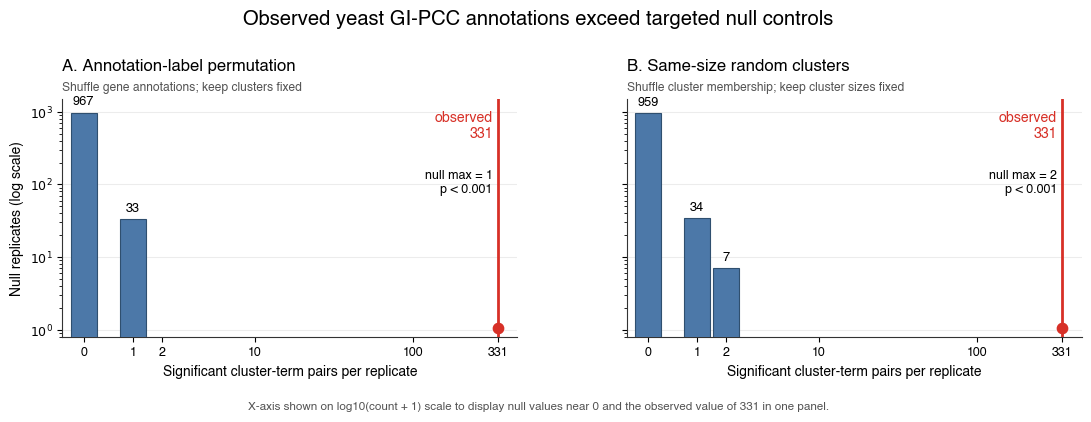

In [4]:
import numpy as np

LABEL_COLOR = "black"
FONT = "Helvetica"
OBSERVED_COLOR = "#d73027"
NULL_COLOR = "#4c78a8"
BAR_EDGE = "#2f4f6f"
GRID_COLOR = "#e6e6e6"

null_panels = [
    {
        "panel": "A",
        "title": "Annotation-label permutation",
        "question": "Shuffle gene annotations; keep clusters fixed",
        "dist": perm_null_dist,
        "observed": int(perm_row["observed_value"]),
        "null_max": int(perm_row["null_max"]),
        "empirical_p": float(perm_row["empirical_pvalue"]),
        "x_values": [0, 1],
    },
    {
        "panel": "B",
        "title": "Same-size random clusters",
        "question": "Shuffle cluster membership; keep cluster sizes fixed",
        "dist": rand_null_dist,
        "observed": int(rand_row["observed_value"]),
        "null_max": int(rand_row["null_max"]),
        "empirical_p": float(rand_row["empirical_pvalue"]),
        "x_values": [0, 1, 2],
    },
]

assert null_panels[0]["dist"]["n_sig"].value_counts().sort_index().to_dict() == {0: 967, 1: 33}
assert null_panels[1]["dist"]["n_sig"].value_counts().sort_index().to_dict() == {0: 959, 1: 34, 2: 7}
assert all(panel["observed"] == 331 for panel in null_panels)


def x_transform(values):
    values = np.asarray(values, dtype=float)
    return np.log10(values + 1.0)


fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.25), sharey=True)
fig.patch.set_facecolor("white")

x_tick_values = [0, 1, 2, 10, 100, 331]
x_tick_positions = x_transform(x_tick_values)

for ax, panel in zip(axes, null_panels):
    counts = panel["dist"]["n_sig"].value_counts().reindex(panel["x_values"], fill_value=0).sort_index()
    x_raw = counts.index.to_numpy()
    x_pos = x_transform(x_raw)
    y = counts.to_numpy()

    ax.bar(
        x_pos,
        y,
        width=0.16,
        color=NULL_COLOR,
        edgecolor=BAR_EDGE,
        linewidth=0.8,
        align="center",
        zorder=3,
    )
    for xi, yi in zip(x_pos, y):
        ax.text(
            xi,
            yi * 1.16,
            f"{yi}",
            ha="center",
            va="bottom",
            fontsize=9.2,
            color=LABEL_COLOR,
            fontname=FONT,
        )

    obs_x = float(x_transform([panel["observed"]])[0])
    ax.axvline(obs_x, color=OBSERVED_COLOR, linewidth=2.0, zorder=4)
    ax.scatter([obs_x], [1.05], color=OBSERVED_COLOR, s=55, zorder=5, clip_on=False)
    ax.text(
        obs_x - 0.03,
        650,
        "observed\n331",
        ha="right",
        va="center",
        fontsize=10.2,
        color=OBSERVED_COLOR,
        fontname=FONT,
    )
    ax.text(
        obs_x - 0.03,
        105,
        f"null max = {panel['null_max']}\np < 0.001",
        ha="right",
        va="center",
        fontsize=9.0,
        color=LABEL_COLOR,
        fontname=FONT,
    )

    ax.set_title(
        f"{panel['panel']}. {panel['title']}",
        loc="left",
        fontsize=12,
        fontname=FONT,
        color=LABEL_COLOR,
        pad=20,
    )
    ax.text(
        0,
        1.02,
        panel["question"],
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8.7,
        color="#555555",
        fontname=FONT,
    )
    ax.set_xlabel("Significant cluster-term pairs per replicate", fontsize=10, fontname=FONT)
    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels([str(v) for v in x_tick_values], fontsize=8.8, fontname=FONT)
    ax.set_xlim(-0.13, obs_x + 0.12)
    ax.set_yscale("log")
    ax.set_ylim(0.8, 1500)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, alpha=0.75, which="major")
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")
    ax.tick_params(axis="both", labelsize=9)

axes[0].set_ylabel("Null replicates (log scale)", fontsize=10, fontname=FONT)
fig.suptitle(
    "Observed yeast GI-PCC annotations exceed targeted null controls",
    fontsize=14.5,
    fontweight="normal",
    color=LABEL_COLOR,
    fontname=FONT,
    y=0.99,
)
fig.text(
    0.50,
    0.055,
    "X-axis shown on log10(count + 1) scale to display null values near 0 and the observed value of 331 in one panel.",
    ha="center",
    va="center",
    fontsize=8.4,
    color="#555555",
    fontname=FONT,
)
fig.subplots_adjust(left=0.075, right=0.985, top=0.78, bottom=0.22, wspace=0.24)
save_figure_png("null_validation_two_panel", fig=fig)
plt.show()


## Caption / Claim Boundary

**Supplementary Figure S3. Null validation of yeast GI-PCC annotations.** The observed reference clustering contains 331 significant cluster-term pairs at q≤0.05. The null distributions are shown directly on a log-scaled count axis: in 1000 annotation-label permutations, 967 replicates produced 0 significant pairs and 33 produced 1; the null maximum was 1 (empirical p = 0.000999, reported in the figure as p < 0.001). In 1000 same-size random cluster partitions, 959 replicates produced 0 significant pairs, 34 produced 1, and 7 produced 2; the null maximum was 2 (empirical p = 0.000999, reported in the figure as p < 0.001). The x-axis uses log10(count + 1) so the zero-heavy null distributions and the observed value can be displayed together without an axis break.

These two controls address complementary arbitrariness concerns: whether enrichment could arise from arbitrary annotation labels, and whether it could arise from arbitrary same-size cluster partitions. Both nulls are scoped to the manual yeast GI-PCC reference configuration (`linkage_threshold=16`, `min_cluster_size=30`) used throughout this figure package. The result does not claim superiority over any alternative clustering method; it shows that the observed enrichment signal is not reproduced by either targeted null control.